In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn 
bc_id=sklearn.datasets.load_breast_cancer( as_frame=True)
X, Y = bc_id.data, bc_id.target
feature_names=bc_id.feature_names

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset
<img source=https://www.researchgate.net/profile/Glaucia-Sizilio/publication/232811011/viewer/AS:117721912057856@1405078499347/background/5.png>

 <img src=https://storage.googleapis.com/kaggle-datasets-images/180/384/3da2510581f9d3b902307ff8d06fe327/dataset-cover.jpg>

In [2]:
from sklearn.preprocessing import StandardScaler
X_sca = StandardScaler()
X = X_sca.fit_transform(X)

In [3]:
X.shape,Y.shape

((569, 30), (569,))

In [60]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

kfold_cv = KFold(n_splits=10)
correct = 0
total = 0

for train_indices, test_indices in kfold_cv.split(X):
    X_train, X_test, y_train, y_test = X[train_indices], X[test_indices], y[train_indices], y[test_indices]
#    learner = LogisticRegression(l1_ratio=1,solver='liblinear').fit(X_train, y_train)
    learner = LogisticRegression().fit(X_train, y_train)

    correct += accuracy_score(y_test, learner.predict(X_test))
    total += 1
    
print("Accuracy: {0:.2f}".format(correct/total))

Accuracy: 0.98


In [102]:
all_data_learner = LogisticRegression().fit(X, Y)
most_important=np.argsort(np.abs(all_data_learner.coef_[0]))[::-1]
for f,c,i in zip(feature_names[most_important],all_data_learner.coef_[0][most_important],most_important):
    print(f"{i}: {f} {c}")

21: worst texture -1.3205563355653767
10: radius error -1.289261391058457
20: worst radius -1.0265855206892538
13: area error -0.9988609264065397
23: worst area -0.9946710096842343
7: mean concave points -0.9628492791726081
27: worst concave points -0.9251751648213165
28: worst symmetry -0.8887113062614864
26: worst concavity -0.8802231400543097
6: mean concavity -0.8552954644402123
22: worst perimeter -0.8203966696990914
15: compactness error 0.7440772761354872
19: fractal dimension error 0.6817461599960514
12: perimeter error -0.6718953978619
24: worst smoothness -0.6657151910556208
5: mean compactness 0.5607070102399466
29: worst fractal dimension -0.4869903565302289
3: mean area -0.439469046482675
1: mean texture -0.38203063629276995
0: mean radius -0.3754573121827312
2: mean perimeter -0.36097104519318873
9: mean fractal dimension 0.32845810317254504
17: concave points error -0.32314491708681126
18: symmetry error 0.2950438590180483
14: smoothness error -0.27950864514842577
11: te

In [103]:
all_data_learner = LogisticRegression(l1_ratio=1,solver='liblinear').fit(X, Y)
most_important=np.argsort(np.abs(all_data_learner.coef_[0]))[::-1]
for f,c,i in zip(feature_names[most_important],all_data_learner.coef_[0][most_important],most_important):
    print(f"{i}: {f} {c}")


10: radius error -2.703403244203666
23: worst area -2.6144816974541794
20: worst radius -1.854044887465542
21: worst texture -1.7851682187258089
27: worst concave points -1.2947912202553216
26: worst concavity -1.0741754889815363
7: mean concave points -1.0733728223314165
15: compactness error 0.8511304906018424
28: worst symmetry -0.5508446804363338
24: worst smoothness -0.541887315307099
11: texture error 0.39707866779298473
14: smoothness error -0.31623218722626184
19: fractal dimension error 0.2526527443427171
6: mean concavity -0.1386511368337382
9: mean fractal dimension 0.12725845237813668
22: worst perimeter -0.011652372635842866
18: symmetry error 0.000492996896724892
25: worst compactness 0.0
16: concavity error 0.0
17: concave points error 0.0
29: worst fractal dimension 0.0
13: area error 0.0
8: mean symmetry 0.0
12: perimeter error 0.0
5: mean compactness 0.0
4: mean smoothness 0.0
3: mean area 0.0
2: mean perimeter 0.0
1: mean texture 0.0
0: mean radius 0.0


In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
learner = LogisticRegression().fit(X_train, y_train)
y_pred = learner.predict_proba(X_test)

import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

def plot_roc(y_test, learner):
    y_pred = learner.predict_proba(X_test)[:, 1]
    fpr, tpr, ths = roc_curve(y_test, y_pred)
    auc_val = auc(fpr, tpr)
    
    fig = plt.figure(figsize=(12, 8))
    values = []
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twiny
    ax1.plot(fpr, tpr, color="red", label="AUC = {0:.2f}".format(auc_val))
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    plt.title("ROC Curve\n")
    ax1.set_xlim((-0.01, 1.01))
    ax1.set_ylim((-0.01, 1.01))
    ax1.set_xticks(np.linspace(0, 1, 11))
    ax1.plot([0, 1], [0, 1], color="blue")
    ax1.legend(loc="lower right")
    plt.show()

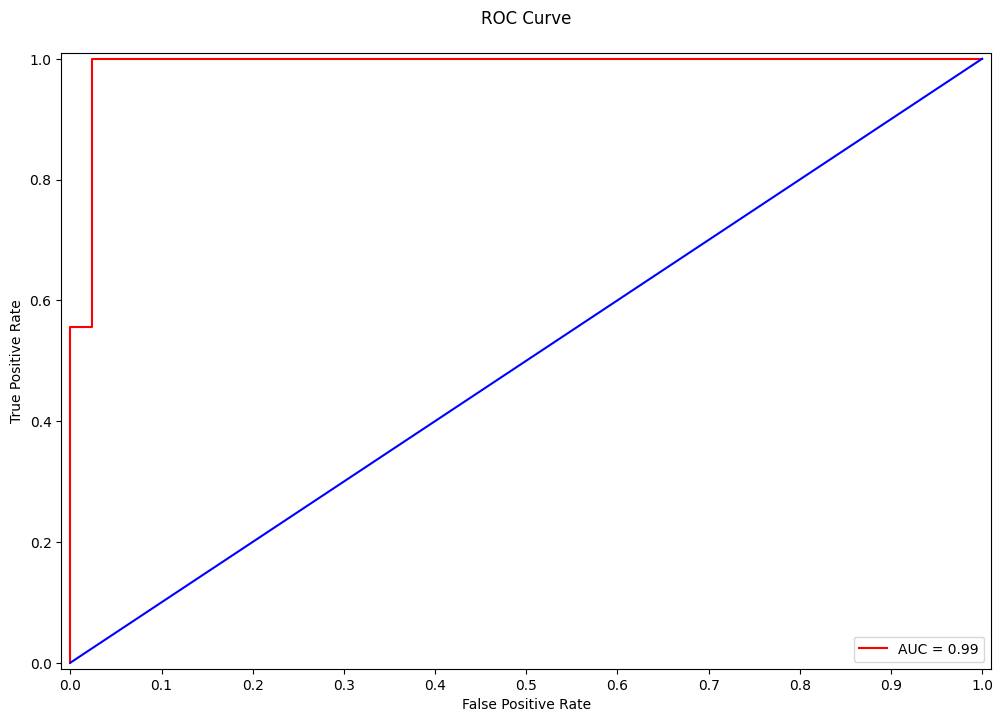

In [19]:
plot_roc(y_test, learner)

<Axes: ylabel='Count'>

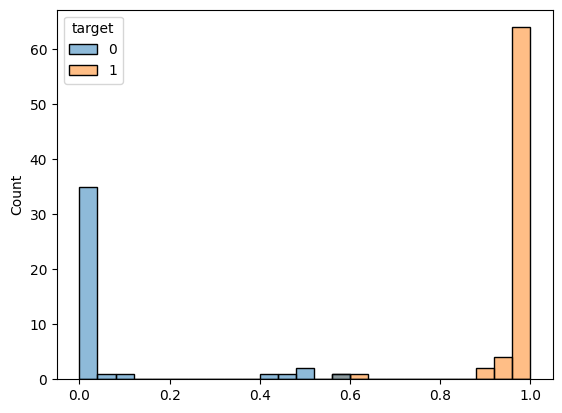

In [100]:
import seaborn as sns
y_pred = learner.predict_proba(X_test)[:, 1]
sns.histplot(x=y_pred,hue=y_test,bins=25)

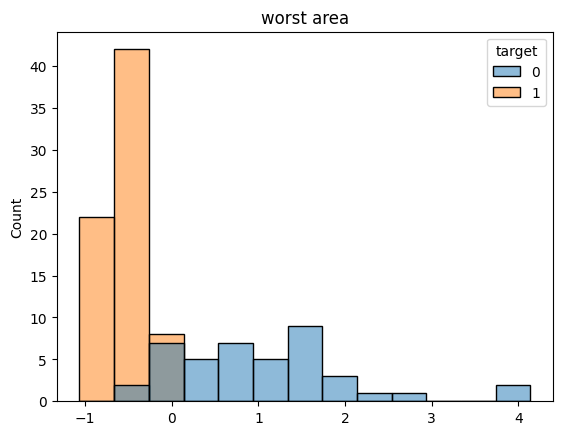

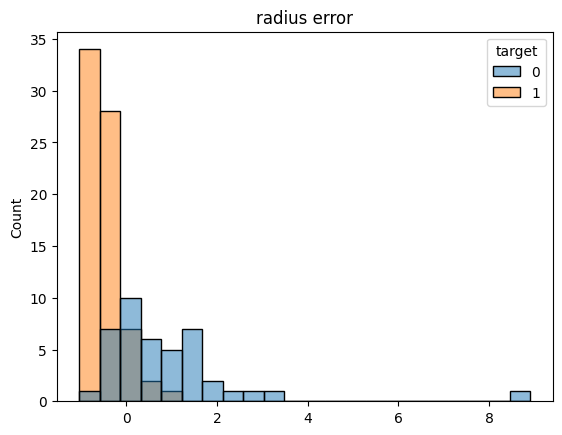

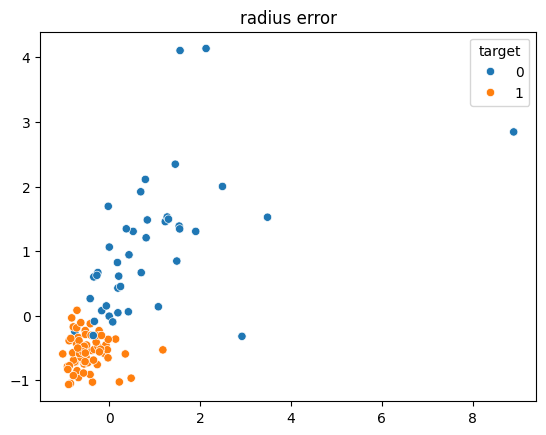

In [110]:
sns.histplot(x=X_test[:,23],hue=y_test)
plt.title(feature_names[23])
plt.show()
sns.histplot(x=X_test[:,10],hue=y_test)
plt.title(feature_names[10])
plt.show()

sns.scatterplot(x=X_test[:,10],y=X_test[:,23],hue=y_test)
plt.title(feature_names[10])
plt.show()